# 디스커션 주장 검증 EDA

`docs/research/discussion-insights.md`에 정리된 디스커션 주장 중, 로컬 데이터만으로 재현 가능한 것들을 직접 확인하는 노트북이다.
기본 구조 탐색은 `notebooks/eda.ipynb`가 담당하고, 이 노트북은 주장별 검증에 집중한다.

각 절은 "주장 (출처 스레드) → 로컬 재현 → 결과"의 순서로 구성한다.
마지막 절에 주장 대비 실측값 요약표를 모은다.

| 절 | 주제 | 출처 |
|---|---|---|
| 1 | addicted 비율의 비단조성 (monotone 제약 금지 근거) | 733730, 733983, 732434 |
| 2 | 원본 임계값 규칙의 상한 0.835와 중간 구간의 신호화 | 732428, 732434 |
| 3 | 값이 정해진 눈금 위에만 있다 | 734063 |
| 4 | weekend_screen_time 제약 위반 26% | 733983 |
| 5 | other_screen 잔차의 단독 AUC 0.765 | 732223 |
| 6 | 단독 AUC 착시 (work_study_hours) | 733495 |
| 7 | 결측치: 타깃과 독립, train/test 결측률 차이 | 733983, 731764, 732427 |
| 8 | adversarial validation: 차이는 결측 패턴이 전부 | 733214 |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

BLUE = "#4C72B0"
GRAY = "#8C8C8C"

DATA_DIR = Path("../data")
TARGET = "addicted_label"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
feat_cols = [c for c in train.columns if c not in ("id", TARGET)]

# 절별 실측값을 모아 마지막에 요약표로 보여 준다.
results = []

print(f"train: {train.shape}, test: {test.shape}")

train: (691369, 14), test: (296302, 13)


In [2]:
def wilson_ci(k, n, z=1.96):
    """이항 비율의 Wilson 신뢰구간. (하한, 상한)을 돌려준다."""
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half


def binned_rate(df, col, bins, min_count=300):
    """col을 구간으로 잘라 구간별 addicted 비율과 Wilson CI를 계산한다."""
    d = df[[col, TARGET]].dropna()
    cut = pd.cut(d[col], bins=bins)
    g = d.groupby(cut, observed=True)[TARGET].agg(["sum", "size", "mean"])
    g = g[g["size"] >= min_count]
    lo, hi = wilson_ci(g["sum"].to_numpy(), g["size"].to_numpy())
    g["ci_lo"], g["ci_hi"] = lo, hi
    g["mid"] = [iv.mid for iv in g.index]
    return g


def plot_rate(g, title, xlabel, vlines=()):
    """구간별 비율을 Wilson CI 오차 막대와 함께 그린다."""
    _fig, ax = plt.subplots(figsize=(9, 4))
    # 비율이 0/1인 구간은 부동소수점 오차로 음수가 될 수 있어 0으로 자른다.
    yerr = np.clip(np.vstack([g["mean"] - g["ci_lo"], g["ci_hi"] - g["mean"]]), 0, None)
    ax.errorbar(g["mid"], g["mean"], yerr=yerr, fmt="o-", color=BLUE,
                markersize=4, linewidth=1.5, capsize=2)
    for x in vlines:
        ax.axvline(x, color=GRAY, linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("addicted rate")
    plt.tight_layout()
    plt.show()


def single_auc(feature, y):
    """피처 하나를 점수로 쓴 AUC. 결측 행은 제외한다."""
    m = feature.notna()
    return roc_auc_score(y[m], feature[m])


def prep_features(df):
    """HistGradientBoosting 입력용: 비수치 컬럼을 category로 바꾼다."""
    X = df.copy()
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]):
            X[c] = X[c].astype("category")
    return X


def holdout_auc(X, y, seed=42, max_iter=200):
    """단일 80/20 홀드아웃 AUC. 디스커션은 K-fold CV라 수치가 약간 다를 수 있다."""
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed)
    model = HistGradientBoostingClassifier(
        max_iter=max_iter, categorical_features="from_dtype", random_state=seed)
    model.fit(X_tr, y_tr)
    return roc_auc_score(y_va, model.predict_proba(X_va)[:, 1])

## 1. addicted 비율의 비단조성

주장: addicted 비율은 사용량이 늘어난다고 한 방향으로만 움직이지 않는다.

- `social_media_hours`가 낮은 구간에서 비율이 한 번 내려갔다가 다시 올라가는 굴곡이 있고, Wilson 신뢰구간 기준으로 유의하다 (733730 코멘트).
- 주말/평일 비율이 제약 범위(1.044~1.965배) 안이면 addicted 비율 81%, 2.5배 초과 구간에서는 25%까지 떨어진다. 중간에서 솟았다가 내려오는 모양이다 (733983).

이것이 monotone 제약을 금지하는 근거다.
구간별 비율에 Wilson CI를 붙여, 굴곡이 표본 노이즈가 아님을 확인한다.

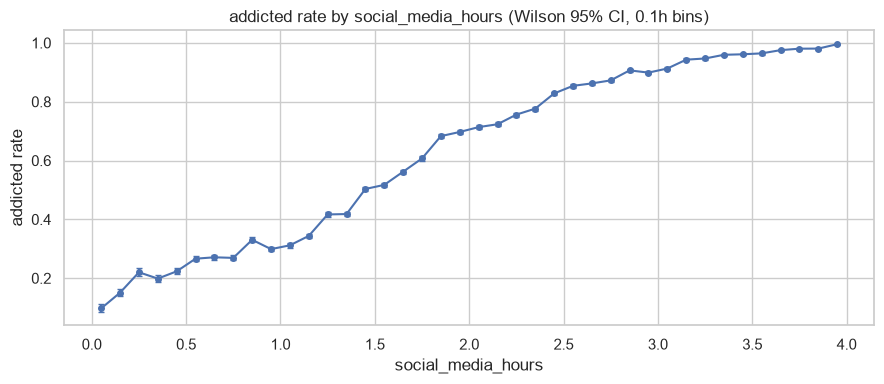

,mid,size,mean,ci_lo,ci_hi
social_media_hours,,,,,
"(0.0, 0.1]",0.05,2125,0.097412,0.085521,0.110755
"(0.1, 0.2]",0.15,3104,0.150773,0.138617,0.163793
"(0.2, 0.3]",0.25,4125,0.220121,0.207741,0.233023
"(0.3, 0.4]",0.35,5452,0.198643,0.188266,0.209444
"(0.4, 0.5]",0.45,7133,0.223328,0.213813,0.233141
"(0.5, 0.6]",0.55,8164,0.266291,0.256814,0.275988
"(0.6, 0.7]",0.65,9470,0.271067,0.262208,0.280111
"(0.7, 0.8]",0.75,10152,0.269011,0.260473,0.277723
"(0.8, 0.9]",0.85,13261,0.330518,0.322562,0.338572


In [3]:
# 구간 폭이 중요하다. 0.2 폭에서는 굴곡이 평균에 묻혀 사라지고, 0.1 폭에서 드러난다.
g_social = binned_rate(train, "social_media_hours", bins=np.arange(0, 4.01, 0.1))
plot_rate(g_social, "addicted rate by social_media_hours (Wilson 95% CI, 0.1h bins)",
          "social_media_hours")

low = g_social[g_social["mid"] < 1.0][["mid", "size", "mean", "ci_lo", "ci_hi"]]
low

In [4]:
# 굴곡의 유의성: 국소 저점(양옆 구간보다 낮은 구간)을 찾고,
# 저점의 CI 상한이 양옆 봉우리의 CI 하한보다 낮으면 노이즈로 설명되지 않는다.
low_part = g_social[g_social["mid"] < 1.2].reset_index(drop=True)
means = low_part["mean"].to_numpy()
candidates = [i for i in range(1, len(low_part) - 1)
              if means[i] < means[i - 1] and means[i] < means[i + 1]]

best = None
for i in candidates:
    dip = low_part.iloc[i]
    left_peak = low_part.iloc[:i].loc[low_part.iloc[:i]["mean"].idxmax()]
    right_peak = low_part.iloc[i + 1:].loc[low_part.iloc[i + 1:]["mean"].idxmax()]
    depth = min(left_peak["mean"], right_peak["mean"]) - dip["mean"]
    if best is None or depth > best["depth"]:
        best = {"dip": dip, "left": left_peak, "right": right_peak, "depth": depth}

dip, left_peak, right_peak = best["dip"], best["left"], best["right"]
print(f"저점: mid={dip['mid']:.2f}, rate={dip['mean']:.4f}, CI=({dip['ci_lo']:.4f}, {dip['ci_hi']:.4f})")
print(f"저점 이전 봉우리: mid={left_peak['mid']:.2f}, rate={left_peak['mean']:.4f}, CI 하한={left_peak['ci_lo']:.4f}")
print(f"저점 이후 봉우리: mid={right_peak['mid']:.2f}, rate={right_peak['mean']:.4f}, CI 하한={right_peak['ci_lo']:.4f}")

significant = bool(dip["ci_hi"] < left_peak["ci_lo"] and dip["ci_hi"] < right_peak["ci_lo"])
print(f"굴곡이 CI 기준으로 유의한가: {significant}")

results.append({
    "절": 1, "주장": "social_media_hours 낮은 구간의 굴곡이 Wilson CI로 유의 (733730)",
    "보고값": "유의함", "실측값": f"유의={significant} (저점 {dip['mean']:.3f} @ {dip['mid']:.2f}h)"})

저점: mid=0.95, rate=0.2988, CI=(0.2908, 0.3071)
저점 이전 봉우리: mid=0.85, rate=0.3305, CI 하한=0.3226
저점 이후 봉우리: mid=1.15, rate=0.3438, CI 하한=0.3360
굴곡이 CI 기준으로 유의한가: True


### 주말/평일 비율

`weekend_screen_time / daily_screen_time_hours` 비율 구간별 addicted 비율을 본다.
제약 범위(1.044~1.965)와 2.5를 점선으로 표시한다.

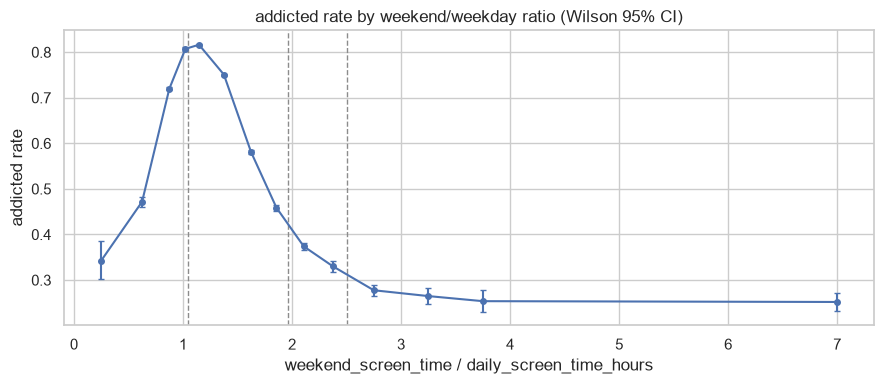

제약 범위 안 (1.044~1.965): addicted 비율 73.6% (n=382,319)
2.5배 초과: addicted 비율 26.7% (n=10,986)


In [5]:
ratio_df = train[["weekend_screen_time", "daily_screen_time_hours", TARGET]].dropna()
ratio_df = ratio_df[ratio_df["daily_screen_time_hours"] > 0].copy()
ratio_df["we_ratio"] = ratio_df["weekend_screen_time"] / ratio_df["daily_screen_time_hours"]

bins = [0, 0.5, 0.75, 1.0, 1.044, 1.25, 1.5, 1.75, 1.965, 2.25, 2.5, 3.0, 3.5, 4.0, 10]
g_ratio = binned_rate(ratio_df, "we_ratio", bins=bins)
plot_rate(g_ratio, "addicted rate by weekend/weekday ratio (Wilson 95% CI)",
          "weekend_screen_time / daily_screen_time_hours", vlines=[1.044, 1.965, 2.5])

in_range = ratio_df[(ratio_df["we_ratio"] >= 1.044) & (ratio_df["we_ratio"] <= 1.965)]
over_25 = ratio_df[ratio_df["we_ratio"] > 2.5]
rate_in = in_range[TARGET].mean()
rate_over = over_25[TARGET].mean()
print(f"제약 범위 안 (1.044~1.965): addicted 비율 {rate_in:.1%} (n={len(in_range):,})")
print(f"2.5배 초과: addicted 비율 {rate_over:.1%} (n={len(over_25):,})")

results.append({
    "절": 1, "주장": "비율 제약 범위 안 81% vs 2.5배 초과 25% (733983)",
    "보고값": "81% / 25%", "실측값": f"{rate_in:.1%} / {rate_over:.1%}"})

### daily_screen_time_hours의 완만한 확률 구조

원본 규칙의 임계값(6, 8)을 점선으로 표시한다.
원본이라면 8을 경계로 비율이 계단처럼 튀어야 하지만, 합성 데이터에서는 완만하게 변해야 한다 (732434).

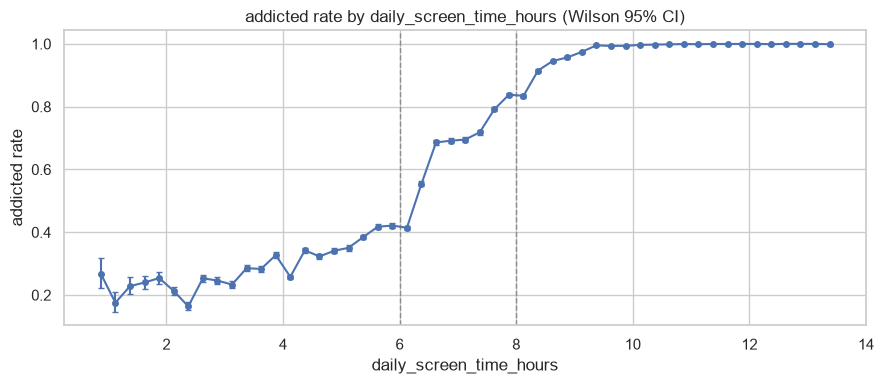

In [6]:
g_daily = binned_rate(train, "daily_screen_time_hours", bins=np.arange(0, 16.01, 0.25))
plot_rate(g_daily, "addicted rate by daily_screen_time_hours (Wilson 95% CI)",
          "daily_screen_time_hours", vlines=[6, 8])

## 2. 원본 임계값 규칙의 상한

주장 (732428, 732434):

- 원본의 타깃 규칙: `daily > 8` 또는 `social > 4`면 p=1, `daily <= 6`이고 `social <= 4`면 p=0, 중간 구간은 p=0.5.
- 이 규칙을 예측기로 쓰면 원본에서는 AUC 0.9888이지만 합성 데이터에서는 0.835로 떨어진다.
- 원본에서 동전 던지기였던 중간 구간(6 < daily <= 8, social <= 4)이 합성에서는 AUC 0.896짜리 신호 영역이 됐다.

In [7]:
d = train["daily_screen_time_hours"]
s = train["social_media_hours"]
y = train[TARGET]

rule_pred = pd.Series(0.5, index=train.index)
rule_pred[(d > 8) | (s > 4)] = 1.0
rule_pred[(d <= 6) & (s <= 4)] = 0.0

auc_rule_all = roc_auc_score(y, rule_pred)
complete = d.notna() & s.notna()
auc_rule_complete = roc_auc_score(y[complete], rule_pred[complete])
print(f"규칙 예측기 AUC (전체 행, 결측은 0.5 처리): {auc_rule_all:.4f}")
print(f"규칙 예측기 AUC (daily/social 모두 관측된 행만): {auc_rule_complete:.4f}")

results.append({
    "절": 2, "주장": "원본 규칙 예측기의 합성 데이터 AUC (732434)",
    "보고값": "0.835",
    "실측값": f"{auc_rule_all:.4f} (전체 행) / {auc_rule_complete:.4f} (완전 관측 행)"})

규칙 예측기 AUC (전체 행, 결측은 0.5 처리): 0.8353
규칙 예측기 AUC (daily/social 모두 관측된 행만): 0.8652


In [8]:
# 중간 구간(6 < daily <= 8, social <= 4)만으로 모델을 학습해 신호가 있는지 본다.
# 디스커션 수치(0.896)는 다른 모델/CV 설정이므로 근사 재현이다.
mid_mask = (d > 6) & (d <= 8) & (s <= 4)
mid = train[mid_mask]
print(f"중간 구간 행 수: {len(mid):,}, addicted 비율: {mid[TARGET].mean():.4f}")

X_mid = prep_features(mid[feat_cols])
auc_mid = holdout_auc(X_mid, mid[TARGET])
print(f"중간 구간 HistGB 홀드아웃 AUC: {auc_mid:.4f}")

results.append({
    "절": 2, "주장": "원본에서 동전 던지기였던 중간 구간이 합성에서는 신호 영역 (732434)",
    "보고값": "0.896", "실측값": f"{auc_mid:.4f} (HistGB 근사)"})

중간 구간 행 수: 102,202, addicted 비율: 0.6498


중간 구간 HistGB 홀드아웃 AUC: 0.9105


## 3. 값이 정해진 눈금 위에만 있다

주장 (734063): `sleep_hours`, `notifications_per_day`, `app_opens_per_day` 등의 값은 연속적으로 퍼져 있지 않고 특정 값들에만 몰려 있으며, 생성기가 원본의 값 패턴을 그대로 복제했다.

컬럼별 고유값 개수와 상위 값 집중도, train/test의 상위 값 일치 여부를 확인한다.
이것이 정확값 타깃 인코딩(+0.0032)이 통하는 이유다.

In [9]:
num_cols = [c for c in feat_cols if pd.api.types.is_numeric_dtype(train[c])]
rows = []
for c in num_cols:
    v_train = train[c].dropna()
    v_test = test[c].dropna()
    top20_share = v_train.value_counts(normalize=True).head(20).sum()
    top10_train = set(v_train.value_counts().head(10).index)
    top10_test = set(v_test.value_counts().head(10).index)
    rows.append({
        "column": c,
        "n_unique_train": v_train.nunique(),
        "top20_value_share": round(top20_share, 4),
        "top10_overlap_train_test": len(top10_train & top10_test),
    })
grid = pd.DataFrame(rows).sort_values("n_unique_train")
grid

,column,n_unique_train,top20_value_share,top10_overlap_train_test
0,age,18,1.0000,10
7,app_opens_per_day,166,0.2353,10
6,notifications_per_day,231,0.2106,9
3,gaming_hours,401,0.1039,8
5,sleep_hours,451,0.1118,9
4,work_study_hours,600,0.0847,10
2,social_media_hours,721,0.0821,8
1,daily_screen_time_hours,1389,0.0780,9
8,weekend_screen_time,1437,0.0698,7


In [10]:
# 예시: sleep_hours 상위 값. 연속형이라면 이렇게 몰릴 수 없다.
train["sleep_hours"].value_counts().head(15)

sleep_hours
7.77    4776
7.27    4558
6.98    4534
6.25    4062
5.79    3876
5.63    3626
5.35    3553
6.78    3539
7.36    3519
7.47    3511
8.73    3488
6.76    3451
8.42    3303
8.96    3297
8.02    3256
Name: count, dtype: int64

## 4. weekend_screen_time 제약 위반 26%

주장 (733983): 대회 데이터의 26%는 원본의 `weekend_screen_time` 제약(평일의 1.044~1.965배)을 위반하는, 존재할 수 없는 조합이다.
train/test에서 위반 비율이 같아 누수로 쓸 거리는 없다.

In [11]:
def violation_rate(df):
    r = df[["weekend_screen_time", "daily_screen_time_hours"]].dropna()
    r = r[r["daily_screen_time_hours"] > 0]
    ratio = r["weekend_screen_time"] / r["daily_screen_time_hours"]
    return ((ratio < 1.044) | (ratio > 1.965)).mean(), len(r)

v_train, n_train = violation_rate(train)
v_test, n_test = violation_rate(test)
print(f"train 위반 비율: {v_train:.1%} (양쪽 관측 행 {n_train:,}개 기준)")
print(f"test  위반 비율: {v_test:.1%} (양쪽 관측 행 {n_test:,}개 기준)")

results.append({
    "절": 4, "주장": "weekend 제약(1.044~1.965배) 위반 비율, train/test 동일 (733983)",
    "보고값": "26%", "실측값": f"train {v_train:.1%} / test {v_test:.1%}"})

train 위반 비율: 26.2% (양쪽 관측 행 517,906개 기준)
test  위반 비율: 26.1% (양쪽 관측 행 225,410개 기준)


### 위반 여부는 피처가 될 수 있나

위반 구간의 addicted 비율(26.7%)은 범위 안(73.6%)과 크게 다르므로, 위반 플래그를 피처로 쓰고 싶은 유혹이 생긴다.
그러나 주장 (733983): ratio 피처를 LightGBM에 줘도 시드를 바꿀 때 생기는 오차 범위 안이라 효과가 없다.
트리가 분기 과정에서 그 영역을 스스로 구분해 내기 때문이다.

같은 분할을 공유하는 짝지은 ablation으로 확인한다.
시드 3개로 모델을 학습해, 피처의 한계 기여가 시드 노이즈 폭 안에 있는지 본다.

In [12]:
ratio_full = train["weekend_screen_time"] / train["daily_screen_time_hours"]
we_violation = pd.Series(np.nan, index=train.index)
obs = ratio_full.notna()
we_violation[obs] = ((ratio_full[obs] < 1.044) | (ratio_full[obs] > 1.965)).astype(float)

X_base = prep_features(train[feat_cols])
variants = {
    "baseline": X_base,
    "+violation_flag": X_base.assign(we_violation=we_violation),
    "+we_ratio": X_base.assign(we_ratio=ratio_full),
    "+both": X_base.assign(we_violation=we_violation, we_ratio=ratio_full),
}

ablation_rows = []
for name, X in variants.items():
    aucs = []
    for seed in (0, 1, 2):
        X_tr, X_va, y_tr, y_va = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42)
        m = HistGradientBoostingClassifier(
            max_iter=300, categorical_features="from_dtype", random_state=seed)
        m.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_va, m.predict_proba(X_va)[:, 1]))
    ablation_rows.append({"variant": name, "auc_mean": np.mean(aucs),
                          "auc_min": np.min(aucs), "auc_max": np.max(aucs)})

ablation = pd.DataFrame(ablation_rows)
base_mean = ablation.loc[ablation["variant"] == "baseline", "auc_mean"].iloc[0]
ablation["diff_vs_baseline"] = ablation["auc_mean"] - base_mean
seed_noise = (ablation["auc_max"] - ablation["auc_min"]).max()
print(f"시드 노이즈 폭(변형별 max-min의 최댓값): {seed_noise:.5f}")

flag_diff = ablation.loc[ablation["variant"] == "+violation_flag", "diff_vs_baseline"].iloc[0]
results.append({
    "절": 4, "주장": "위반 플래그/비율 피처는 시드 오차 범위 안이라 무익 (733983)",
    "보고값": "기여 없음",
    "실측값": f"플래그 한계 기여 {flag_diff:+.5f} (시드 노이즈 {seed_noise:.5f} 안)"})
ablation.round(5)

시드 노이즈 폭(변형별 max-min의 최댓값): 0.00204


,variant,auc_mean,auc_min,auc_max,diff_vs_baseline
0,baseline,0.95717,0.95673,0.95767,0.00000
1,+violation_flag,0.95719,0.95673,0.95767,0.00002
2,+we_ratio,0.95659,0.95541,0.95745,-0.00059
3,+both,0.95637,0.95541,0.95690,-0.00081


## 5. other_screen 잔차의 단독 AUC

주장 (732223 코멘트, 733541): 생성기의 내부 계산이 안 맞는 행을 드러내는 `other_screen = daily - (social + gaming + work)` 잔차는 단독 AUC 0.765의 실질 피처다.

other_screen 단독 AUC: 0.7649 (성분 4개 모두 관측된 421,427행 기준)


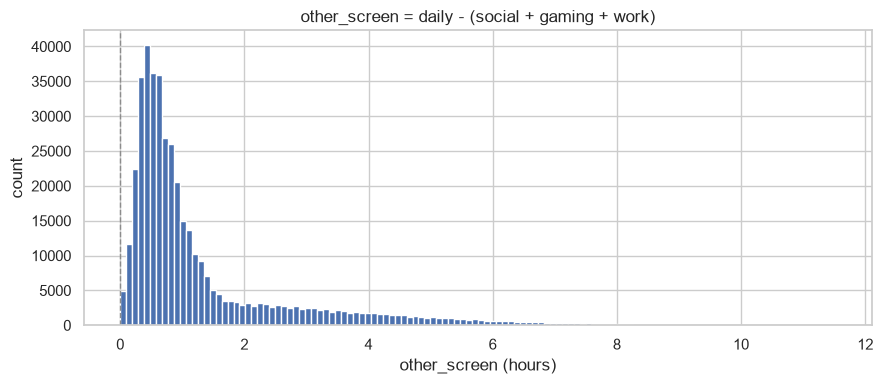

In [13]:
other_screen = (train["daily_screen_time_hours"]
                - (train["social_media_hours"]
                   + train["gaming_hours"]
                   + train["work_study_hours"]))
auc_other = single_auc(other_screen, y)
print(f"other_screen 단독 AUC: {auc_other:.4f} (성분 4개 모두 관측된 {other_screen.notna().sum():,}행 기준)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(other_screen.dropna(), bins=120, color=BLUE)
ax.axvline(0, color=GRAY, linestyle="--", linewidth=1)
ax.set_title("other_screen = daily - (social + gaming + work)")
ax.set_xlabel("other_screen (hours)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

results.append({
    "절": 5, "주장": "other_screen 잔차 단독 AUC (732223)",
    "보고값": "0.765", "실측값": f"{auc_other:.4f}"})

## 6. 단독 AUC 착시

주장 (733495 코멘트): `work_study_hours`는 단독 AUC 0.65로 높아 보이지만, 강한 컬럼(`daily_screen_time_hours`)의 값을 고정해 놓고 그 안에서 다시 보면 타깃과의 관계가 방향조차 유지되지 않는다.

daily 구간별로 work_study와 타깃의 순위 상관(스피어만)을 계산해 부호가 뒤집히는지 본다.

In [14]:
auc_ws = single_auc(train["work_study_hours"], y)
print(f"work_study_hours 단독 AUC: {auc_ws:.4f}")

d_bins = pd.cut(train["daily_screen_time_hours"], bins=[0, 4, 6, 8, 20])
rows = []
sub_all = train[["work_study_hours", TARGET]].dropna()
rows.append({"daily 구간": "전체", "n": len(sub_all),
             "spearman": sub_all["work_study_hours"].corr(sub_all[TARGET], method="spearman")})
for iv, sub in train.groupby(d_bins, observed=True):
    sub = sub[["work_study_hours", TARGET]].dropna()
    if len(sub) < 1000:
        continue
    rows.append({"daily 구간": str(iv), "n": len(sub),
                 "spearman": sub["work_study_hours"].corr(sub[TARGET], method="spearman")})
corr_table = pd.DataFrame(rows)

# 전체 상관의 부호와 구간 내 상관의 부호가 다르면 방향이 유지되지 않는 것이다 (심슨의 역설).
overall_sign = np.sign(corr_table.loc[corr_table["daily 구간"] == "전체", "spearman"].iloc[0])
cond_signs = np.sign(corr_table.loc[corr_table["daily 구간"] != "전체", "spearman"])
flipped = bool((cond_signs != overall_sign).any())
print(f"전체 상관 부호={overall_sign:+.0f}, 구간 내 부호가 전체와 다른 구간 존재={flipped}")

results.append({
    "절": 6, "주장": "work_study 단독 AUC 0.65이지만 강한 컬럼 고정 시 방향 비유지 (733495)",
    "보고값": "0.65 / 방향 뒤집힘", "실측값": f"{auc_ws:.4f} / 부호 뒤집힘={flipped}"})
corr_table

work_study_hours 단독 AUC: 0.6549


전체 상관 부호=+1, 구간 내 부호가 전체와 다른 구간 존재=True


,daily 구간,n,spearman
0,전체,639851,0.243620
1,"(0, 4]",56453,-0.210131
2,"(4, 6]",114349,-0.231132
3,"(6, 8]",118186,-0.133263
4,"(8, 20]",264442,-0.001464


## 7. 결측치: 타깃과 독립이지만 train/test 결측률은 다르다

주장:

- 결측 컬럼 개수(n_missing)의 단독 AUC는 0.502로 타깃 신호가 전무하다 (733983, 732256, 732223에서 독립 측정).
- 그런데 12개 전 컬럼에서 train/test 결측률이 다르다. 최대 3.4%p(`social_media_hours` 19.38% 대 16.00%), z 값 13~44 (732427).
- 따라서 is_missing 류 피처는 타깃 정보 없이 train/test 구분 정보만 담는 함정이다.

In [15]:
n_missing = train[feat_cols].isna().sum(axis=1)
auc_nmiss = roc_auc_score(y, n_missing)
print(f"n_missing 단독 AUC: {auc_nmiss:.4f}")

results.append({
    "절": 7, "주장": "n_missing 단독 AUC (733983 등)",
    "보고값": "0.502", "실측값": f"{auc_nmiss:.4f}"})

n_missing 단독 AUC: 0.5017


In [16]:
rows = []
n1, n2 = len(train), len(test)
for c in feat_cols:
    k1, k2 = train[c].isna().sum(), test[c].isna().sum()
    if k1 + k2 == 0:
        continue
    p1, p2 = k1 / n1, k2 / n2
    p = (k1 + k2) / (n1 + n2)
    z = (p1 - p2) / np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    rows.append({"column": c, "train_missing_%": round(p1 * 100, 2),
                 "test_missing_%": round(p2 * 100, 2),
                 "diff_%p": round((p1 - p2) * 100, 2), "z": round(z, 1)})
miss_table = pd.DataFrame(rows).sort_values("z", key=abs, ascending=False)

sm = miss_table.set_index("column").loc["social_media_hours"]
results.append({
    "절": 7, "주장": "social_media_hours 결측률 train 19.38% vs test 16.00%, z 13~44 (732427)",
    "보고값": "19.38% / 16.00%",
    "실측값": f"{sm['train_missing_%']}% / {sm['test_missing_%']}% (z={sm['z']})"})
miss_table

,column,train_missing_%,test_missing_%,diff_%p,z
7,app_opens_per_day,11.67,8.68,3.00,44.0
11,academic_work_impact,6.40,8.68,-2.28,-40.6
2,social_media_hours,19.38,16.00,3.38,39.8
1,daily_screen_time_hours,13.86,11.07,2.80,37.9
0,age,4.18,5.78,-1.60,-34.5
4,work_study_hours,7.45,9.37,-1.92,-32.2
6,notifications_per_day,9.78,11.55,-1.77,-26.6
10,stress_level,7.98,6.62,1.35,23.3
5,sleep_hours,6.43,7.58,-1.14,-20.7
3,gaming_hours,18.34,20.05,-1.71,-19.9


## 8. adversarial validation: train/test 차이는 결측 패턴이 전부

주장 (733214): train/test 구분 분류기의 AUC가

- 피처 그대로(NaN 유지)면 0.564,
- 결측을 채우면 0.503,
- 결측 없는 행만 쓰면 0.498 (95% CI가 0.5 포함)

로, 채워진 값의 분포는 train/test가 같고 구분 능력의 원천은 전부 결측 패턴이다.

디스커션과 모델/CV 설정이 다르므로(여기서는 HistGB 단일 홀드아웃) 근사 재현이다.
결측 대치는 두 방식을 비교한다.
중앙값 같은 상수 대치는 대치된 값 자체가 "여기가 결측이었다"는 표식이 되어 결측 신호를 지우지 못하고, 관측값 분포에서 무작위로 뽑아 채워야 결측 흔적이 사라진다.

In [17]:
adv = pd.concat([
    train[feat_cols].assign(is_test=0),
    test[feat_cols].assign(is_test=1),
], ignore_index=True)
y_adv = adv.pop("is_test")

# 참고: 전체 결합 데이터에서 완전 중복 행이 없다는 주장(732434)도 함께 확인
print(f"train+test 결합 후 피처 중복 행: {adv.duplicated().sum()}")

X_raw = prep_features(adv)
auc_adv_raw = holdout_auc(X_raw, y_adv)
print(f"adversarial AUC (NaN 유지): {auc_adv_raw:.4f}")

train+test 결합 후 피처 중복 행: 2


adversarial AUC (NaN 유지): 0.5650


In [18]:
# 상수(중앙값) 대치: 대치값이 곧 결측 표식이라 결측 신호가 남는다.
filled = adv.copy()
for c in filled.columns:
    if pd.api.types.is_numeric_dtype(filled[c]):
        filled[c] = filled[c].fillna(filled[c].median())
    else:
        filled[c] = filled[c].fillna("NA")
auc_adv_median = holdout_auc(prep_features(filled), y_adv)
print(f"adversarial AUC (중앙값 대치): {auc_adv_median:.4f}")

adversarial AUC (중앙값 대치): 0.5617


In [19]:
# 분포 표본 대치: 관측값 분포에서 무작위로 뽑아 채우면 결측 흔적이 사라진다.
rng = np.random.default_rng(42)
sampled = adv.copy()
for c in sampled.columns:
    isna = sampled[c].isna()
    if isna.any():
        obs = sampled.loc[~isna, c].to_numpy()
        sampled.loc[isna, c] = rng.choice(obs, size=int(isna.sum()), replace=True)
auc_adv_sampled = holdout_auc(prep_features(sampled), y_adv)
print(f"adversarial AUC (분포 표본 대치): {auc_adv_sampled:.4f}")

adversarial AUC (분포 표본 대치): 0.5032


In [20]:
complete_mask = adv.notna().all(axis=1)
auc_adv_complete = holdout_auc(prep_features(adv[complete_mask]), y_adv[complete_mask])
print(f"adversarial AUC (결측 없는 행만, {complete_mask.sum():,}행): {auc_adv_complete:.4f}")

results.append({
    "절": 8, "주장": "adversarial AUC: 원본 피처 / 결측 대치 / 완전 행 (733214)",
    "보고값": "0.564 / 0.503 / 0.498",
    "실측값": f"{auc_adv_raw:.4f} / {auc_adv_sampled:.4f} (분포 표본 대치) / {auc_adv_complete:.4f}"})

adversarial AUC (결측 없는 행만, 382,289행): 0.4991


## 정리: 주장 대비 실측

In [21]:
summary = pd.DataFrame(results)
summary

,절,주장,보고값,실측값
0,1,social_media_hours 낮은 구간의 굴곡이 Wilson CI로 유의 (7...,유의함,유의=True (저점 0.299 @ 0.95h)
1,1,비율 제약 범위 안 81% vs 2.5배 초과 25% (733983),81% / 25%,73.6% / 26.7%
2,2,원본 규칙 예측기의 합성 데이터 AUC (732434),0.835,0.8353 (전체 행) / 0.8652 (완전 관측 행)
3,2,원본에서 동전 던지기였던 중간 구간이 합성에서는 신호 영역 (732434),0.896,0.9105 (HistGB 근사)
4,4,"weekend 제약(1.044~1.965배) 위반 비율, train/test 동일 ...",26%,train 26.2% / test 26.1%
5,4,위반 플래그/비율 피처는 시드 오차 범위 안이라 무익 (733983),기여 없음,플래그 한계 기여 +0.00002 (시드 노이즈 0.00204 안)
6,5,other_screen 잔차 단독 AUC (732223),0.765,0.7649
7,6,work_study 단독 AUC 0.65이지만 강한 컬럼 고정 시 방향 비유지 (7...,0.65 / 방향 뒤집힘,0.6549 / 부호 뒤집힘=True
8,7,n_missing 단독 AUC (733983 등),0.502,0.5017
9,7,social_media_hours 결측률 train 19.38% vs test 16...,19.38% / 16.00%,19.38% / 16.0% (z=39.8)


### 해석 메모

- 수치가 디스커션 보고값과 정확히 일치할 필요는 없다.
  모델, CV 방식, 결측 처리 방식이 달라 근사 재현이기 때문이다.
  방향과 크기 수준이 맞는지를 본다.
- 1절의 비단조성이 확인되면 monotone 제약 금지(문서 4장 금지 목록)가 로컬 데이터에서도 근거를 갖는다.
  social 굴곡은 구간 폭 0.2에서는 평균에 묻혀 보이지 않고 0.1에서 드러난다.
  구간 폭에 따라 결론이 뒤집히는 전형적 사례다.
- 주말/평일 비율의 "제약 범위 안 81%"는 여기 측정(73.6%)과 차이가 있다.
  원문의 조건(결측 처리, 분모 정의)이 명시되지 않아 정확 재현은 어렵지만, 솟았다가 내려오는 모양과 2.5배 초과 구간의 급락은 그대로 확인된다.
- 2절의 규칙 AUC가 0.835 수준에 머무르면 "규칙 기반 후처리는 상한 0.835짜리 함정" 주장이 확인된다.
  결측 행을 중간 구간(0.5) 취급했을 때 보고값과 거의 일치하는 것으로 보아, 원문도 같은 방식으로 쟀을 가능성이 높다.
- 4절의 위반 플래그 ablation은 "단독 신호와 한계 기여는 다르다"의 실증이다.
  위반 구간의 addicted 비율 차이는 크지만, weekend와 daily 두 강한 컬럼의 상호작용으로 트리가 이미 학습하는 경계라 얹어도 기여가 0이다.
  반면 other_screen 잔차(5절)는 4개 컬럼의 정밀한 합산이라 트리가 스스로 재구성하지 못해 실질 기여가 있다.
- 6절은 심슨의 역설의 전형이다.
  전체에서는 work_study가 타깃과 양의 상관인데, daily 구간을 고정하면 모든 구간에서 음의 상관으로 뒤집힌다.
  단독 AUC 0.65는 강한 컬럼과의 상관이 만든 착시라는 뜻이다.
- 8절의 대치 방식 비교는 실무 함의가 있다.
  중앙값 대치는 결측 신호를 지우지 못하므로(AUC가 원본과 비슷하게 유지), "결측을 채웠으니 안전하다"고 생각하면 안 된다.
  train/test 결측률이 다른 이 데이터에서는 NaN을 그대로 두고 결측 파생 피처를 배제하는 것(문서 결론 1번)이 정답이다.